In [ ]:
!pip install -q pycbc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 74.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.7/168.7 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 MB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.1/51.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.1/203.1 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.0/115.0 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.1/48.1 MB 11.0 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
from pycbc.waveform import get_td_waveform

os.makedirs("data", exist_ok=True)
os.makedirs("figures", exist_ok=True)

sample_rate = 4096
delta_t = 1.0 / sample_rate

mass1 = 36
mass2 = 29
distance = 410

hp, hc = get_td_waveform(
    approximant="IMRPhenomD",
    mass1=mass1,
    mass2=mass2,
    spin1z=0,
    spin2z=0,
    distance=distance,
    delta_t=delta_t,
    f_lower=20
)

t = np.array(hp.sample_times)
y = np.array(hp)

mask = (t >= -1.0) & (t <= 0.05)

t_crop = t[mask]
clean = y[mask]
clean = clean / np.max(np.abs(clean))

np.random.seed(42)
noise_level = 0.35
noise = noise_level * np.random.normal(0, 1, size=len(clean))
noisy = clean + noise

np.save("data/t_crop.npy", t_crop)
np.save("data/clean_waveform.npy", clean)
np.save("data/noisy_waveform_noise_035.npy", noisy)

print("Data recreated and saved.")
print("t_crop:", t_crop.shape)
print("clean:", clean.shape)
print("noisy:", noisy.shape)

/usr/lib/python3.12/importlib/__init__.py:90: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  return _bootstrap._gcd_import(name[level:], package, level)


Data recreated and saved.
t_crop: (4301,)
clean: (4301,)
noisy: (4301,)


In [ ]:
from scipy.stats import pearsonr

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def correlation(y_true, y_pred):
    return pearsonr(y_true, y_pred)[0]

def snr_db(clean_signal, test_signal):
    signal_power = np.mean(clean_signal ** 2)
    noise_power = np.mean((clean_signal - test_signal) ** 2)
    return 10 * np.log10(signal_power / noise_power)

def evaluate_method(name, clean_signal, denoised_signal):
    return {
        "Method": name,
        "MSE": mse(clean_signal, denoised_signal),
        "MAE": mae(clean_signal, denoised_signal),
        "Correlation": correlation(clean_signal, denoised_signal),
        "SNR_dB": snr_db(clean_signal, denoised_signal)
    }

In [ ]:
baseline_result = evaluate_method("Noisy input", clean, noisy)
baseline_result

{'Method': 'Noisy input',
 'MSE': np.float64(0.12203725502700226),
 'MAE': np.float64(0.27835429269369816),
 'Correlation': np.float64(0.5601654942771584),
 'SNR_dB': np.float64(-3.3132641848434363)}

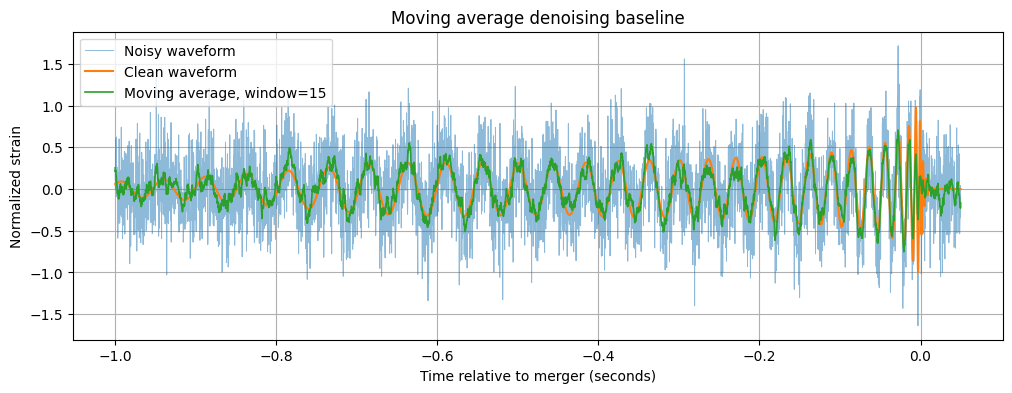

In [ ]:
from scipy.ndimage import uniform_filter1d

window_size = 15
moving_avg = uniform_filter1d(noisy, size=window_size)

plt.figure(figsize=(12, 4))
plt.plot(t_crop, noisy, label="Noisy waveform", linewidth=0.7, alpha=0.5)
plt.plot(t_crop, clean, label="Clean waveform", linewidth=1.5)
plt.plot(t_crop, moving_avg, label=f"Moving average, window={window_size}", linewidth=1.2)

plt.xlabel("Time relative to merger (seconds)")
plt.ylabel("Normalized strain")
plt.title("Moving average denoising baseline")
plt.legend()
plt.grid(True)

plt.savefig("figures/01_moving_average_baseline.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
#The moving average filter reduces random fluctuations in the noisy waveform and roughly follows the clean BBH waveform. However, because it performs simple local averaging, it can smooth sharp oscillatory features near the merger region. This shows that classical smoothing can suppress noise but may distort physically important waveform structures.

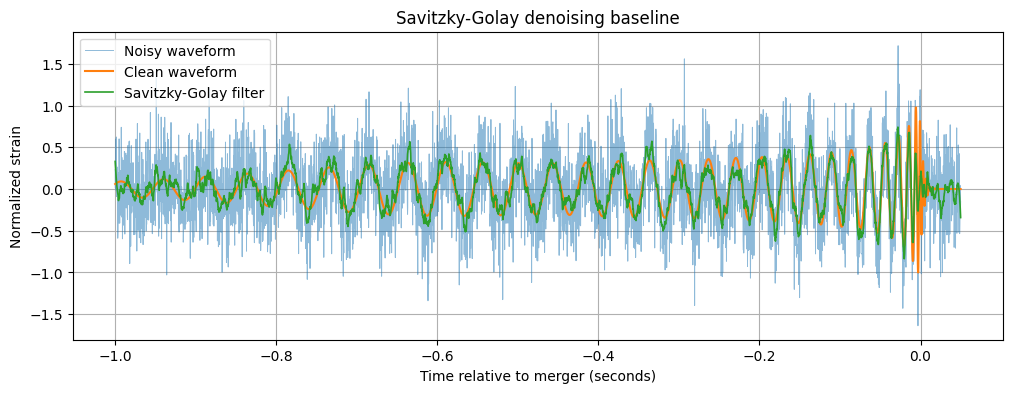

In [ ]:
from scipy.signal import savgol_filter

savgol = savgol_filter(noisy, window_length=31, polyorder=3)

plt.figure(figsize=(12, 4))
plt.plot(t_crop, noisy, label="Noisy waveform", linewidth=0.7, alpha=0.5)
plt.plot(t_crop, clean, label="Clean waveform", linewidth=1.5)
plt.plot(t_crop, savgol, label="Savitzky-Golay filter", linewidth=1.2)

plt.xlabel("Time relative to merger (seconds)")
plt.ylabel("Normalized strain")
plt.title("Savitzky-Golay denoising baseline")
plt.legend()
plt.grid(True)

plt.savefig("figures/02_savgol_baseline.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
#The Savitzky-Golay filter reduces random noise while preserving the oscillatory structure better than simple moving average smoothing. However, it still struggles near the merger region, where the waveform changes rapidly. This suggests that classical filters may reduce noise but can distort sharp gravitational-wave features.

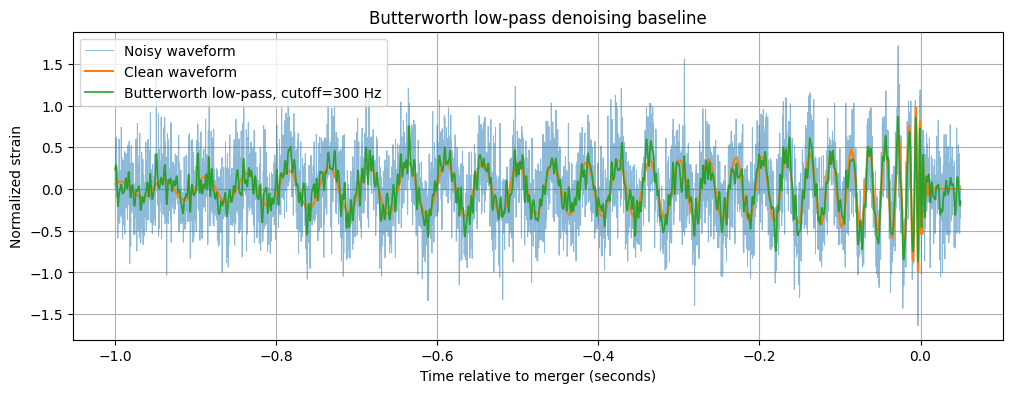

In [ ]:
from scipy.signal import butter, filtfilt

sample_rate = 4096
cutoff_freq = 300

def butter_lowpass_filter(data, cutoff, fs, order=4):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype="low", analog=False)
    return filtfilt(b, a, data)

butter_filtered = butter_lowpass_filter(noisy, cutoff_freq, sample_rate)

plt.figure(figsize=(12, 4))
plt.plot(t_crop, noisy, label="Noisy waveform", linewidth=0.7, alpha=0.5)
plt.plot(t_crop, clean, label="Clean waveform", linewidth=1.5)
plt.plot(t_crop, butter_filtered, label=f"Butterworth low-pass, cutoff={cutoff_freq} Hz", linewidth=1.2)

plt.xlabel("Time relative to merger (seconds)")
plt.ylabel("Normalized strain")
plt.title("Butterworth low-pass denoising baseline")
plt.legend()
plt.grid(True)

plt.savefig("figures/03_butterworth_lowpass_baseline.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
import pandas as pd

results = []

results.append(evaluate_method("Noisy input", clean, noisy))
results.append(evaluate_method("Moving average", clean, moving_avg))
results.append(evaluate_method("Savitzky-Golay", clean, savgol))
results.append(evaluate_method("Butterworth low-pass", clean, butter_filtered))

results_df = pd.DataFrame(results)
results_df

,Method,MSE,MAE,Correlation,SNR_dB
0,Noisy input,0.122037,0.278354,0.560165,-3.313264
1,Moving average,0.010304,0.076847,0.909802,7.421608
2,Savitzky-Golay,0.011409,0.080138,0.903700,6.979375
3,Butterworth low-pass,0.015445,0.099473,0.884149,5.663662


In [ ]:
#The classical filtering baseline shows that simple smoothing methods significantly improve waveform recovery compared with the noisy input. The moving average filter achieved the lowest MSE and highest SNR among the tested classical methods, while the Savitzky-Golay filter produced similar performance with slightly lower correlation. The Butterworth low-pass filter reduced noise but performed worse than the smoothing-based filters in this controlled Gaussian-noise setting. These results provide a baseline that the autoencoder model must outperform or match in later experiments.

In [ ]:
noise_levels = [0.1, 0.25, 0.35, 0.5, 0.75]

all_results = []

for nl in noise_levels:
    np.random.seed(42)
    noise = nl * np.random.normal(0, 1, size=len(clean))
    noisy_signal = clean + noise

    moving_avg_signal = uniform_filter1d(noisy_signal, size=15)
    savgol_signal = savgol_filter(noisy_signal, window_length=31, polyorder=3)
    butter_signal = butter_lowpass_filter(noisy_signal, cutoff_freq, sample_rate)

    for method_name, signal in [
        ("Noisy input", noisy_signal),
        ("Moving average", moving_avg_signal),
        ("Savitzky-Golay", savgol_signal),
        ("Butterworth low-pass", butter_signal)
    ]:
        result = evaluate_method(method_name, clean, signal)
        result["Noise_Level"] = nl
        all_results.append(result)

multi_noise_df = pd.DataFrame(all_results)
multi_noise_df

,Method,MSE,MAE,Correlation,SNR_dB,Noise_Level
0,Noisy input,0.009962,0.079530,0.922131,7.568097,0.10
1,Moving average,0.002673,0.026549,0.976940,13.282249,0.10
2,Savitzky-Golay,0.003061,0.026755,0.972757,12.693196,0.10
3,Butterworth low-pass,0.001312,0.028818,0.988537,16.373257,0.10
4,Noisy input,0.062264,0.198824,0.688516,-0.390703,0.25
5,Moving average,0.006251,0.056560,0.943883,9.592449,0.25
6,Savitzky-Golay,0.006974,0.058749,0.938685,9.116647,0.25
7,Butterworth low-pass,0.007904,0.071145,0.935756,8.573091,0.25
8,Noisy input,0.122037,0.278354,0.560165,-3.313264,0.35
9,Moving average,0.010304,0.076847,0.909802,7.421608,0.35


In [ ]:
multi_noise_df.to_csv("data/classical_filtering_multi_noise_results.csv", index=False)
print("Saved multi-noise classical baseline results.")

Saved multi-noise classical baseline results.


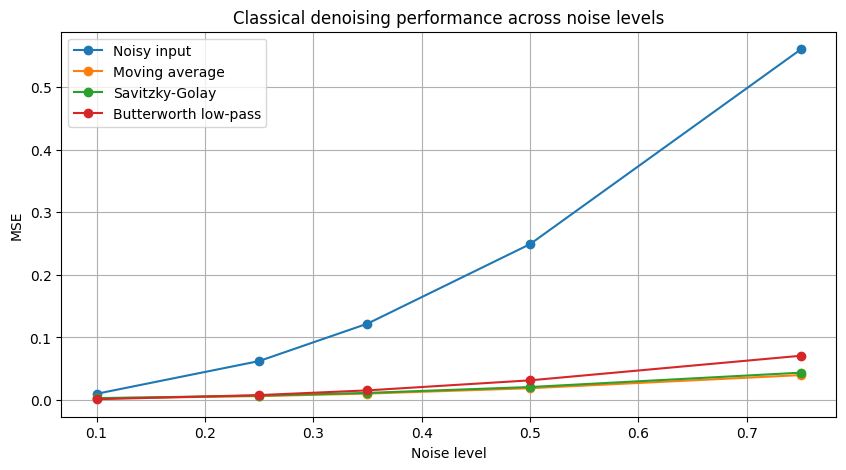

In [ ]:
plt.figure(figsize=(10, 5))

for method in multi_noise_df["Method"].unique():
    subset = multi_noise_df[multi_noise_df["Method"] == method]
    plt.plot(subset["Noise_Level"], subset["MSE"], marker="o", label=method)

plt.xlabel("Noise level")
plt.ylabel("MSE")
plt.title("Classical denoising performance across noise levels")
plt.legend()
plt.grid(True)

plt.savefig("figures/05_mse_vs_noise_level_classical.png", dpi=300, bbox_inches="tight")
plt.show()

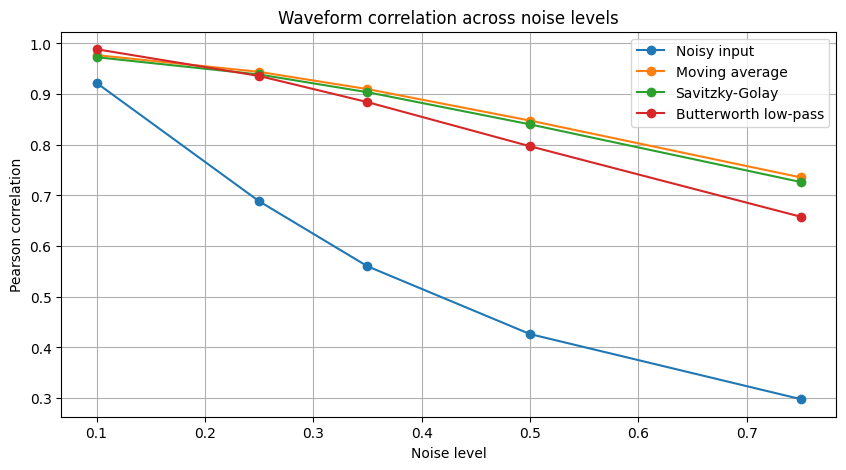

In [ ]:
plt.figure(figsize=(10, 5))

for method in multi_noise_df["Method"].unique():
    subset = multi_noise_df[multi_noise_df["Method"] == method]
    plt.plot(subset["Noise_Level"], subset["Correlation"], marker="o", label=method)

plt.xlabel("Noise level")
plt.ylabel("Pearson correlation")
plt.title("Waveform correlation across noise levels")
plt.legend()
plt.grid(True)

plt.savefig("figures/06_correlation_vs_noise_level_classical.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
#Classical filtering significantly improved waveform recovery compared with the raw noisy waveform across all tested noise levels. The noisy input showed a rapid decline in Pearson correlation and a sharp increase in MSE as noise amplitude increased. Among the tested methods, moving average smoothing achieved the best overall performance at moderate-to-high noise levels, while the Butterworth low-pass filter performed strongly at low noise but degraded more rapidly at higher noise. These results establish a quantitative baseline for evaluating the later autoencoder-based denoising model.

In [ ]:
#Important honest limitation : These results are based on controlled Gaussian noise added to a simulated BBH waveform. Real LIGO detector noise is non-Gaussian and non-stationary, so future experiments should test the model on real detector-noise segments.

In [ ]:
multi_noise_df.to_csv("data/classical_filtering_multi_noise_results.csv", index=False)
results_df.to_csv("data/classical_filtering_results_noise_035.csv", index=False)